In [10]:
import os
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [11]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [12]:
classes = ["glioma", "meningioma", "pituitary", "no_tumor"]

In [13]:
data = []

base_path = "dataset_multiclass"

for idx, category in enumerate(classes):
    folder_path = os.path.join(base_path, category)
    
    for img_name in os.listdir(folder_path):
        try:
            img_path = os.path.join(folder_path, img_name)
            img = cv2.imread(img_path)
            img = cv2.resize(img, (128, 128))
            data.append([img, idx])
        except:
            pass

random.shuffle(data)

print("Total images loaded:", len(data))


Total images loaded: 7023


In [14]:
X = []
y = []

for features, label in data:
    X.append(features)
    y.append(label)

X = np.array(X) / 255.0
y = np.array(y)

print("Images shape:", X.shape)
print("Labels shape:", y.shape)


Images shape: (7023, 128, 128, 3)
Labels shape: (7023,)


In [15]:
y = to_categorical(y, num_classes=4)

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 5618
Testing samples: 1405


In [17]:
model = Sequential([
    Input(shape=(128, 128, 3)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(4, activation='softmax')  # 4 classes
])

In [18]:
model.compile(
    optimizer=Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,836 (28.20 MB)

 Trainable params: 7,392,836 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
history = model.fit(
    X_train, y_train,
    epochs=25,
    batch_size=16,
    validation_data=(X_test, y_test)
)

Epoch 1/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 81s 207ms/step - accuracy: 0.7266 - loss: 0.7010 - val_accuracy: 0.8292 - val_loss: 0.4339
Epoch 2/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 68s 192ms/step - accuracy: 0.8608 - loss: 0.3636 - val_accuracy: 0.8847 - val_loss: 0.2767
Epoch 3/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 68s 194ms/step - accuracy: 0.9117 - loss: 0.2352 - val_accuracy: 0.9181 - val_loss: 0.2060
Epoch 4/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 68s 193ms/step - accuracy: 0.9432 - loss: 0.1591 - val_accuracy: 0.9452 - val_loss: 0.1698
Epoch 5/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 65s 185ms/step - accuracy: 0.9548 - loss: 0.1227 - val_accuracy: 0.9488 - val_loss: 0.1492
Epoch 6/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 65s 185ms/step - accuracy: 0.9672 - loss: 0.0875 - val_accuracy: 0.9452 - val_loss: 0.1724
Epoch 7/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 66s 187ms/step - accuracy: 0.9770 - loss: 0.0683 - val_accuracy: 0.9495 - val_loss: 0.1703
Epoch 8/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 89s 252ms/step - accuracy: 0.9794 - loss: 0

In [20]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_accuracy)

44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - accuracy: 0.9630 - loss: 0.2359
Test Accuracy: 0.962989330291748


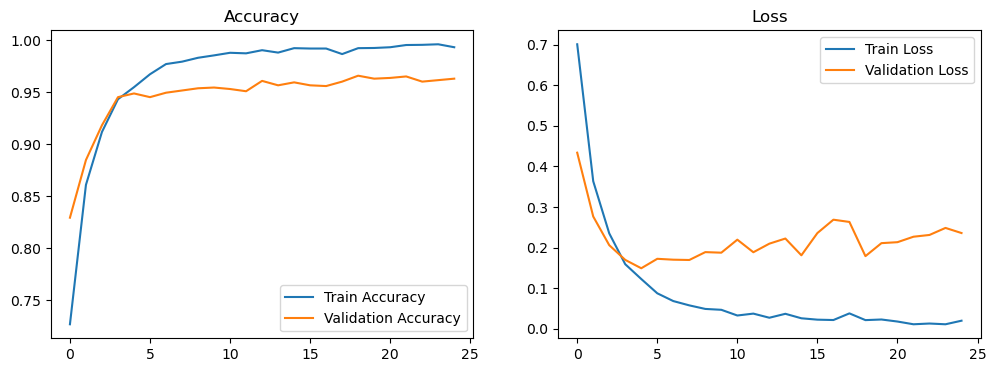

In [21]:
plt.figure(figsize=(12,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy")

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss")

plt.show()

In [22]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(y_true, y_pred_classes, target_names=classes))

44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step
              precision    recall  f1-score   support

      glioma       0.96      0.95      0.95       334
  meningioma       0.92      0.92      0.92       295
   pituitary       0.98      0.99      0.99       374
    no_tumor       0.98      0.98      0.98       402

    accuracy                           0.96      1405
   macro avg       0.96      0.96      0.96      1405
weighted avg       0.96      0.96      0.96      1405



In [24]:
model.save("brain_tumor_multiclass.keras")